In [59]:
# Import data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
# MENGELOMPOKKAN PELANGGAN GROSIR BERDASARKAN JENIS PRODUK YANG DIBELI
# CLUSTERING

data = pd.read_csv("/content/Wholesale customers data.csv")
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [62]:
#Melihat ringkasan statistik dan informasi penting tentang dataset

data.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [63]:
# melihat ada data  yang kosong atau tidak
data.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


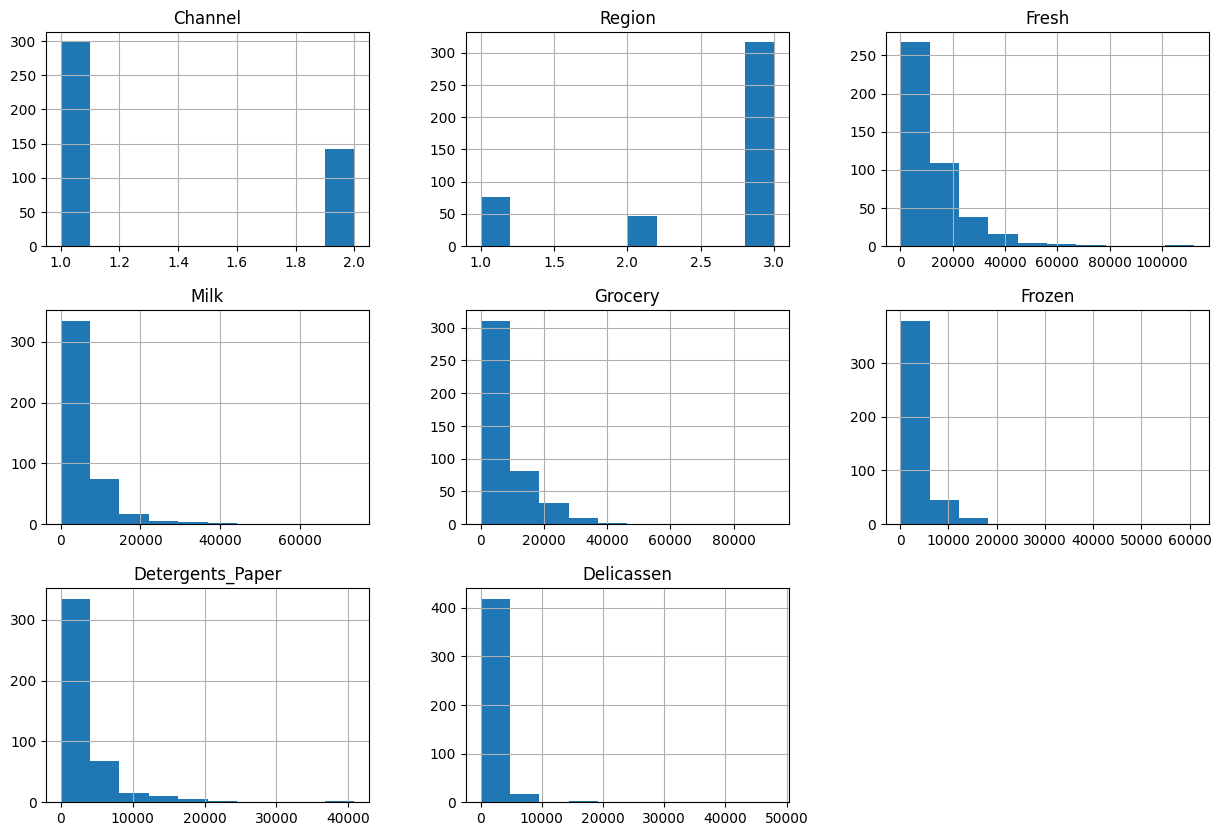

In [64]:
#visualisasi distribusi

data.hist(figsize=(15,10))
plt.show()

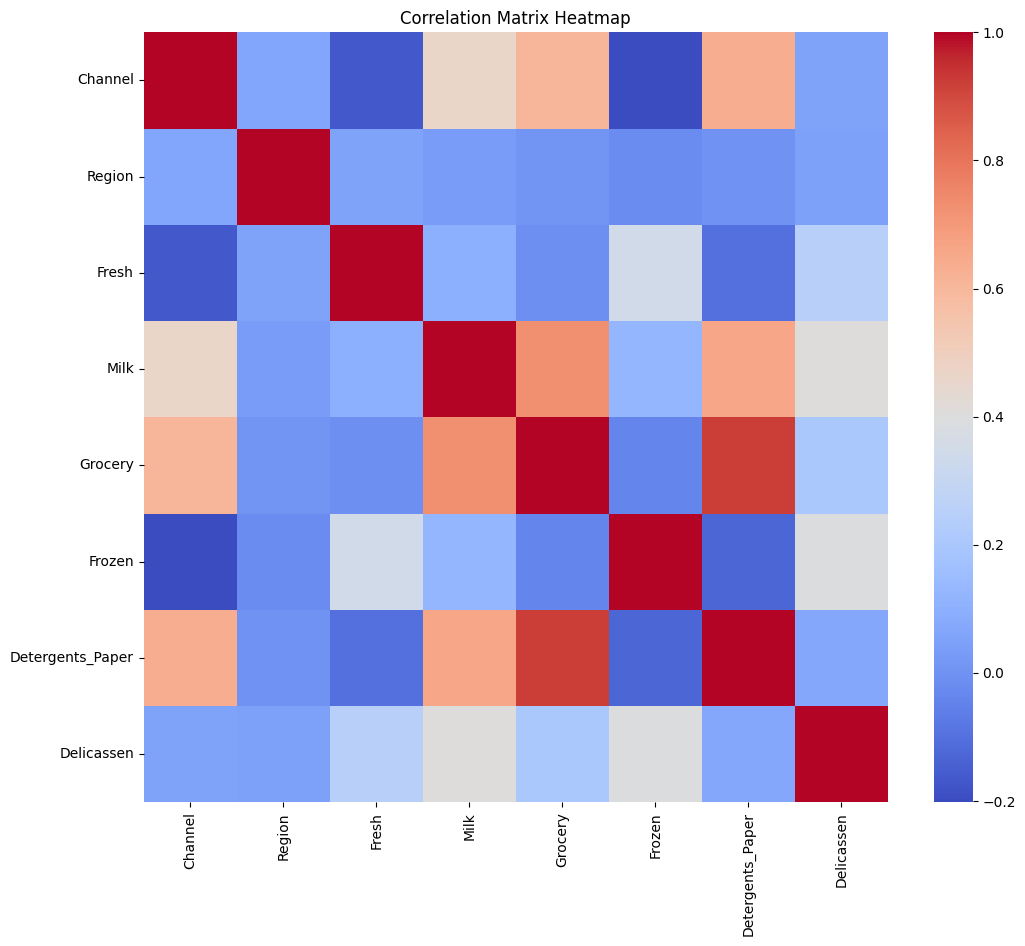

In [65]:
# ANALISIS EDA
# Cek korelasi

correlation_matrix = data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

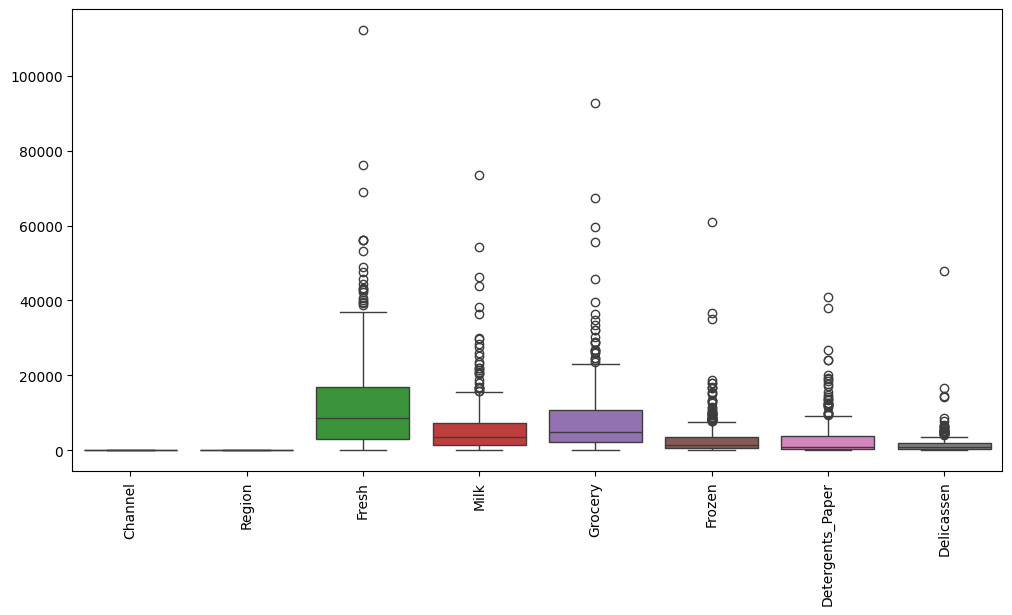

In [66]:
# CEK OUTLIER

plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

In [67]:
# DROP KOLOM CHANNEL DAN REGION

X = data.drop(columns=["Channel", "Region"], axis =  1)

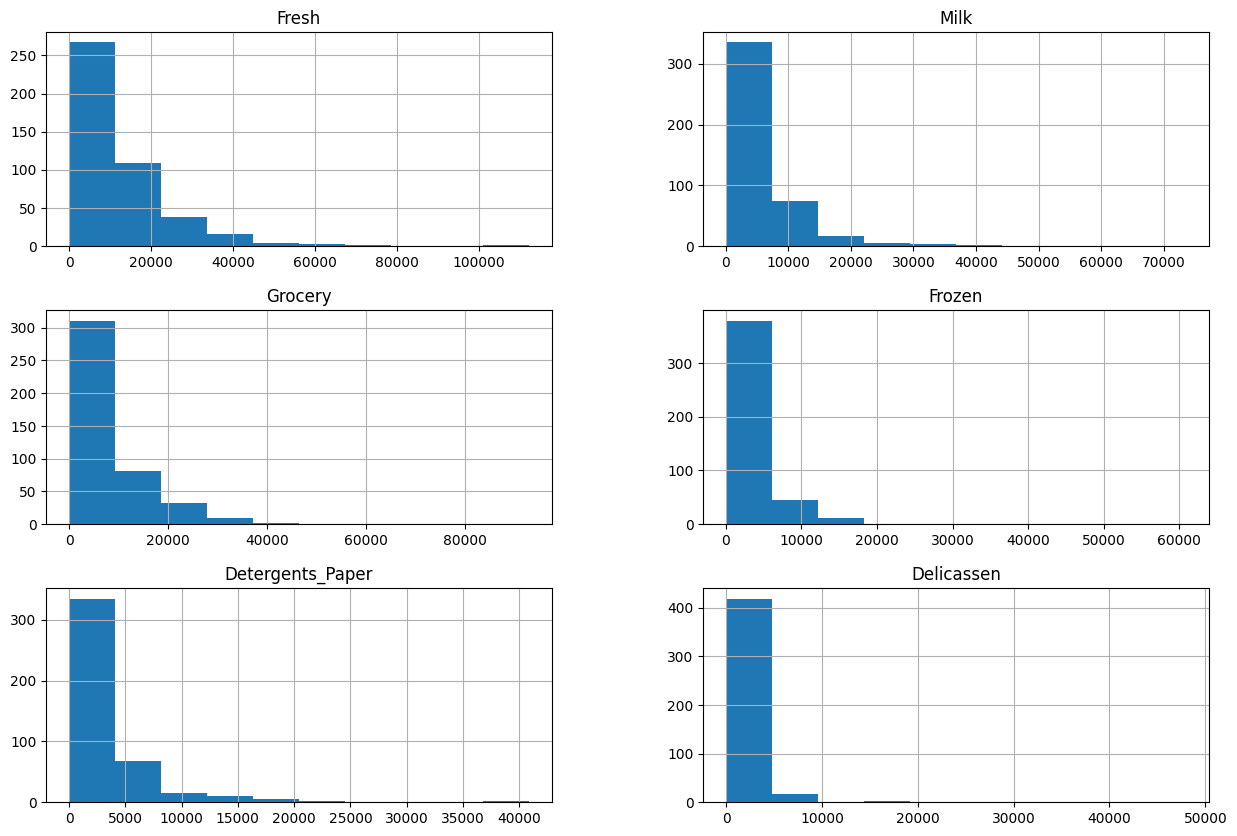

In [68]:
X.hist(figsize=(15,10))
plt.show()

In [69]:
# SCALLING DATA

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [70]:
from sklearn.decomposition import PCA

# PCA ke 2 dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.44082893 0.283764  ]


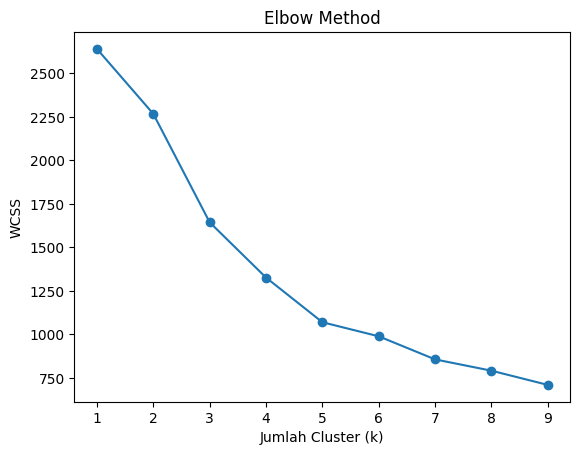

In [71]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. MODEL K-MEANS
# ELBOW METHOD (WCSS)
wcss = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot Elbow
plt.figure()
plt.plot(range(1, 10), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS')
plt.show()

In [72]:
# SILHOUETTE SCORE
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score}")

k=2, silhouette=0.3998278091730005
k=3, silhouette=0.4582633767207058
k=4, silhouette=0.34939129340421093
k=5, silhouette=0.36890127429678043
k=6, silhouette=0.2762464573058837
k=7, silhouette=0.276678268663421
k=8, silhouette=0.32366546538940916
k=9, silhouette=0.29453704649783113


In [73]:
# Model K-Means (training / clustering process)
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

In [74]:
#Hyperparameter Tuning

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_score = -1
best_params = {}
best_model = None

for n_init in [10, 20, 30]:
    for max_iter in [300, 500]:
        for init in ['k-means++', 'random']:

            kmeans = KMeans(
                n_clusters=2,
                n_init=n_init,
                max_iter=max_iter,
                init=init,
                random_state=42
            )

            labels = kmeans.fit_predict(X_scaled)
            score = silhouette_score(X_scaled, labels)

            print(f"init={init}, n_init={n_init}, max_iter={max_iter}, silhouette={score}")

            if score > best_score:
                best_score = score
                best_params = {
                    "init": init,
                    "n_init": n_init,
                    "max_iter": max_iter
                }
                best_model = kmeans

print("\nBest params:", best_params)
print("Best score:", best_score)

init=k-means++, n_init=10, max_iter=300, silhouette=0.5472146913441881
init=random, n_init=10, max_iter=300, silhouette=0.5532526964184259
init=k-means++, n_init=10, max_iter=500, silhouette=0.5472146913441881
init=random, n_init=10, max_iter=500, silhouette=0.5532526964184259
init=k-means++, n_init=20, max_iter=300, silhouette=0.6136936741219485
init=random, n_init=20, max_iter=300, silhouette=0.5532526964184259
init=k-means++, n_init=20, max_iter=500, silhouette=0.6136936741219485
init=random, n_init=20, max_iter=500, silhouette=0.5532526964184259
init=k-means++, n_init=30, max_iter=300, silhouette=0.5810874672125177
init=random, n_init=30, max_iter=300, silhouette=0.5909041986285453
init=k-means++, n_init=30, max_iter=500, silhouette=0.5810874672125177
init=random, n_init=30, max_iter=500, silhouette=0.5909041986285453

Best params: {'init': 'k-means++', 'n_init': 20, 'max_iter': 300}
Best score: 0.6136936741219485


In [75]:
#MODEL FINAL
kmeans_final = KMeans(
    n_clusters=2,
    n_init=best_params["n_init"],
    max_iter=best_params["max_iter"],
    random_state=42
)

labels_final = kmeans_final.fit_predict(X_scaled)

In [76]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# EVALUASI FINAL
print("=== EVALUASI MODEL FINAL K-MEANS ===")
print("Silhouette Score      :", silhouette_score(X_scaled, labels_final))
print("Davies-Bouldin Index :", davies_bouldin_score(X_scaled, labels_final))
print("Calinski-Harabasz    :", calinski_harabasz_score(X_scaled, labels_final))

=== EVALUASI MODEL FINAL K-MEANS ===
Silhouette Score      : 0.6136936741219485
Davies-Bouldin Index : 1.133011168467447
Calinski-Harabasz    : 153.57461665449182


In [77]:
#MENAMBAHKAN KE DATAFRAME

data['Cluster_KMeans'] = labels_final

In [78]:
#CEK

data['Cluster_KMeans'].unique()


array([1, 0], dtype=int32)

In [79]:
data['Cluster_KMeans'].value_counts()

,count
Cluster_KMeans,
1,404
0,36


In [80]:
# 2. MODEL HIERARCHICAL
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Load data
data = data.drop(columns=["Channel", "Region"], errors='ignore')

In [81]:
# Model Hierarchical (training / clustering process)
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)

In [82]:
# HYPERPARAMETER TUNING

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Parameter yang diuji
n_clusters_list = range(2, 7)
linkage_methods = ['ward', 'complete', 'average', 'single']

best_score = -1
best_params = None

print("=== TUNING HIERARCHICAL ===")

for n in n_clusters_list:
    for linkage in linkage_methods:

        model = AgglomerativeClustering(n_clusters=n, linkage=linkage)
        labels_hc_final = model.fit_predict(X_scaled)

        score = silhouette_score(X_scaled, labels)

        print(f"n_clusters={n}, linkage={linkage}, silhouette={score}")

        # Simpan terbaik
        if score > best_score:
            best_score = score
            best_params = (n, linkage)

print("\n=== PARAMETER TERBAIK ===")
print("n_clusters :", best_params[0])
print("linkage    :", best_params[1])
print("Silhouette :", best_score)

=== TUNING HIERARCHICAL ===
n_clusters=2, linkage=ward, silhouette=0.5909041986285453
n_clusters=2, linkage=complete, silhouette=0.5909041986285453
n_clusters=2, linkage=average, silhouette=0.5909041986285453
n_clusters=2, linkage=single, silhouette=0.5909041986285453
n_clusters=3, linkage=ward, silhouette=0.5909041986285453
n_clusters=3, linkage=complete, silhouette=0.5909041986285453
n_clusters=3, linkage=average, silhouette=0.5909041986285453
n_clusters=3, linkage=single, silhouette=0.5909041986285453
n_clusters=4, linkage=ward, silhouette=0.5909041986285453
n_clusters=4, linkage=complete, silhouette=0.5909041986285453
n_clusters=4, linkage=average, silhouette=0.5909041986285453
n_clusters=4, linkage=single, silhouette=0.5909041986285453
n_clusters=5, linkage=ward, silhouette=0.5909041986285453
n_clusters=5, linkage=complete, silhouette=0.5909041986285453
n_clusters=5, linkage=average, silhouette=0.5909041986285453
n_clusters=5, linkage=single, silhouette=0.5909041986285453
n_cluste

In [83]:
# MODEL FINAL HIERARCHICAL

hc_final = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

labels_hc_final = hc_final.fit_predict(X_scaled)

In [84]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# Evaluasi
print("\n=== EVALUASI FINAL HIERARCHICAL ===")
print("Silhouette Score      :", silhouette_score(X_scaled, labels_hc_final))
print("Davies-Bouldin Index :", davies_bouldin_score(X_scaled, labels_hc_final))
print("Calinski-Harabasz    :", calinski_harabasz_score(X_scaled, labels_hc_final))


=== EVALUASI FINAL HIERARCHICAL ===
Silhouette Score      : 0.7924572758342273
Davies-Bouldin Index : 0.9086447273572084
Calinski-Harabasz    : 105.44181523324131


In [85]:
#MENAMBAHKAN KE DATAFRAME

data['cluster_hc'] = labels_hc_final

In [86]:
#CEK

data['cluster_hc'].unique()

array([0, 1])

In [87]:
data['cluster_hc'].value_counts()

,count
cluster_hc,
0,434
1,6


In [88]:
# 3. MODEL DBSCAN

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# MODEL AWAL
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

print("Cluster: ", np.unique(labels_dbscan))

Cluster:  [-1  0]


In [89]:
# Cek cluster valid
print("=== DBSCAN AWAL ===")
if len(set(labels_dbscan)) > 1 and len(set(labels_dbscan)) < len(labels_dbscan):

    # Hilangkan noise (-1)
    mask = labels_dbscan != -1
    X_valid = X_scaled[mask]
    labels_valid = labels_dbscan[mask]

    if len(set(labels_valid)) > 1:
        print("Silhouette Score :", silhouette_score(X_valid, labels_valid))
        print("Davies-Bouldin  :", davies_bouldin_score(X_valid, labels_valid))
        print("Calinski-Harabasz:", calinski_harabasz_score(X_valid, labels_valid))
    else:
        print("Cluster kurang dari 2 setelah hapus noise")
else:
    print("Cluster tidak terbentuk / semua noise")

=== DBSCAN AWAL ===
Cluster kurang dari 2 setelah hapus noise


In [90]:
# HYPERPARAMETERR TUNING DBSCAN

eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 10]

best_score = -1
best_params = None

print("\n=== TUNING DBSCAN ===")

for eps in eps_values:
    for min_s in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbscan.fit_predict(X_scaled)

        # Hapus noise
        mask = labels != -1
        X_valid = X_scaled[mask]
        labels_valid = labels[mask]

        if len(set(labels_valid)) > 1:
            score = silhouette_score(X_valid, labels_valid)
            print(f"eps={eps}, min_samples={min_s}, silhouette={score}")

            if score > best_score:
                best_score = score
                best_params = (eps, min_s)

print("\n=== PARAMETER TERBAIK ===")
print("eps :", best_params[0])
print("min_samples :", best_params[1])
print("Silhouette :", best_score)


=== TUNING DBSCAN ===
eps=0.5, min_samples=3, silhouette=0.13831737718865472
eps=0.5, min_samples=5, silhouette=0.5209785200749437
eps=0.5, min_samples=10, silhouette=0.3725973413236859
eps=1.0, min_samples=3, silhouette=0.4961631671597529
eps=1.5, min_samples=3, silhouette=0.4611118110539028

=== PARAMETER TERBAIK ===
eps : 0.5
min_samples : 5
Silhouette : 0.5209785200749437


In [91]:
# MODEL FINAL DBSCAN
best_dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
final_labels = best_dbscan.fit_predict(X_scaled)

print("\n=== EVALUASI AKHIR DBSCAN ===")

mask = final_labels != -1
X_valid = X_scaled[mask]
labels_valid = final_labels[mask]

if len(set(labels_valid)) > 1:
    print("Silhouette Score :", silhouette_score(X_valid, labels_valid))
    print("Davies-Bouldin  :", davies_bouldin_score(X_valid, labels_valid))
    print("Calinski-Harabasz:", calinski_harabasz_score(X_valid, labels_valid))
else:
    print("Cluster kurang dari 2")


=== EVALUASI AKHIR DBSCAN ===
Silhouette Score : 0.5209785200749437
Davies-Bouldin  : 0.4732753174828166
Calinski-Harabasz: 36.16906294790282


In [92]:
#MENAMBAHKAN KE DATAFRAME

data['cluster_dbscan'] = final_labels

In [93]:
#CEK HASIL

data['cluster_dbscan'].unique()
data['cluster_dbscan'].value_counts()

,count
cluster_dbscan,
0,261
-1,174
1,5


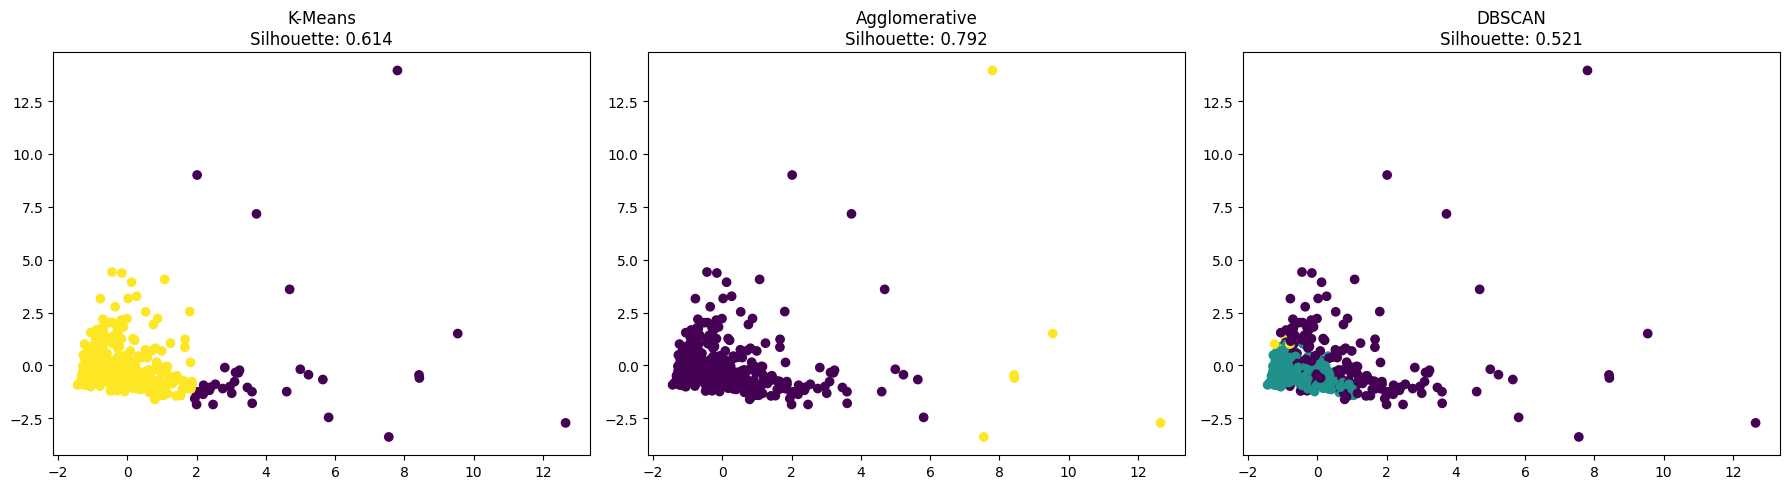

In [94]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Hitung silhouette (WAJIB pakai X_scaled)
sil_kmeans = silhouette_score(X_scaled, labels_final)
sil_hc = silhouette_score(X_scaled, labels_hc_final)

# DBSCAN (Hanya ambil points yang bukan noise)
mask = final_labels != -1

if len(set(final_labels[mask])) > 1:
    sil_dbscan = silhouette_score(X_scaled[mask], final_labels[mask])
else:
    sil_dbscan = -1

# Plot
plt.figure(figsize=(18,5))

# KMeans
plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_final)
plt.title(f"K-Means\nSilhouette: {sil_kmeans:.3f}")

# Agglomerative
plt.subplot(1,3,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_hc_final)
plt.title(f"Agglomerative\nSilhouette: {sil_hc:.3f}")

# DBSCAN
plt.subplot(1,3,3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=final_labels)
plt.title(f"DBSCAN\nSilhouette: {sil_dbscan:.3f}")

plt.tight_layout()
plt.show()